In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
from pathlib import Path

ROOT = Path("..")
MATCHED = ROOT / "data" / "matched"
FIGURES = ROOT / "data" / "figures"
DATA = ROOT / "data"
API_KEY = "A08hCjeUoeVKA9toVsfCpF"

# Load juniors
juniors = pd.read_csv(MATCHED / "junior_authors_all_conferences.csv")
print(juniors.columns.tolist())
print(f"Junior authors: {juniors['author_id'].nunique()}")
print(juniors.head(3))

['award_id', 'conference', 'award_year', 'work_id', 'award_title', 'author_id', 'author_name', 'author_position', 'career_age_at_award', 'total_pubs_at_award', 'institutions', 'is_corresponding', 'match_route', 'core_rank']
Junior authors: 603
   award_id conference  award_year                           work_id  \
0         1       AAAI        2018  https://openalex.org/W2788603415   
1         2        ACL        2018  https://openalex.org/W2798397965   
2         5        CHI        2018  https://openalex.org/W4255717503   

                                         award_title  \
0           Memory-Augmented Monte Carlo Tree Search   
1  Finding syntax in human encephalography with b...   
2            Agile 3D Sketching with Air Scaffolding   

                          author_id       author_name  author_position  \
0  https://openalex.org/A5014823249      Jincheng Mei                2   
1  https://openalex.org/A5069646529  Adhiguna Kuncoro                3   
2  https://openalex.

In [6]:
profiles = pd.read_csv(DATA / "profiles" / "junior_profiles_all.csv")
print(profiles.columns.tolist())
print(profiles.head(3))

['author_id', 'author_name', 'award_year', 'conference', 'career_age_at_award', 'author_position', 'match_route', 'works_count', 'cited_by_count', 'i10_index', '2yr_mean_citedness', 'first_pub_year', 'counts_by_year']
                          author_id       author_name  award_year conference  \
0  https://openalex.org/A5014823249      Jincheng Mei        2018       AAAI   
1  https://openalex.org/A5069646529  Adhiguna Kuncoro        2018        ACL   
2  https://openalex.org/A5032195981      Sang-Gyun An        2018        CHI   

   career_age_at_award  author_position match_route  works_count  \
0                    4                2   SS→DOI→OA           29   
1                    2                3   SS→DOI→OA           35   
2                    1                2   SS→DOI→OA            8   

   cited_by_count  i10_index  2yr_mean_citedness  first_pub_year  \
0             244          9            0.166667            2014   
1            1578         19            0.000000    

In [10]:
import json

records = []
for _, row in profiles.iterrows():
    try:
        year_map = {c['year']: c['works_count'] for c in json.loads(row['counts_by_year'])}
    except:
        year_map = {}
    
    award_yr = int(row['award_year'])
    post_works = sum(year_map.get(award_yr + i, 0) for i in range(1, 6))
    survived = int(post_works > 0)
    
    records.append({
        'author_id': row['author_id'],
        'author_name': row['author_name'],
        'award_year': award_yr,
        'conference': row['conference'],
        'career_age_at_award': row['career_age_at_award'],
        'author_position': row['author_position'],
        'works_count': row['works_count'],
        'cited_by_count': row['cited_by_count'],
        'i10_index': row['i10_index'],
        '2yr_mean_citedness': row['2yr_mean_citedness'],
        'post_works_5yr': post_works,
        'survived': survived
    })

df_surv = pd.DataFrame(records)
print(f"Total juniors: {len(df_surv)}")
print(f"Survived: {df_surv['survived'].sum()} ({df_surv['survived'].mean()*100:.1f}%)")
print(f"Did NOT survive: {(df_surv['survived']==0).sum()}")
print(df_surv.groupby('conference')['survived'].mean().round(3))

Total juniors: 603
Survived: 541 (89.7%)
Did NOT survive: 62
conference
AAAI          0.875
ACL           0.947
CHI           0.840
CIKM          0.917
CVPR          0.909
FOCS          0.727
FSE           0.894
ICCV          0.750
ICML          1.000
ICSE          0.877
IJCAI         1.000
INFOCOM       1.000
KDD           1.000
MOBICOM       0.889
NSDI          1.000
NeurIPS       1.000
OSDI          0.955
PLDI          0.885
PODS          1.000
S&P           0.875
SIGCOMM       1.000
SIGIR         0.778
SIGMETRICS    0.889
SIGMOD        0.833
SODA          0.800
SOSP          1.000
STOC          1.000
UIST          0.778
VLDB          1.000
WWW           1.000
Name: survived, dtype: float64


In [11]:
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── 1. Time-to-dropout: first year post-award with zero publications
dropout_years = []
for _, row in profiles.iterrows():
    try:
        year_map = {c['year']: c['works_count'] for c in json.loads(row['counts_by_year'])}
    except:
        year_map = {}
    award_yr = int(row['award_year'])
    dropout_at = None
    for lag in range(1, 6):
        if year_map.get(award_yr + lag, 0) == 0:
            dropout_at = lag
            break
    dropout_years.append(dropout_at)  # None = censored (still publishing)

df_surv['dropout_lag'] = dropout_years

print("=== Dropout timing (years post-award) ===")
print(df_surv[df_surv['dropout_lag'].notna()]['dropout_lag'].value_counts().sort_index())

# ── 2. Predictors: career age
surv = df_surv[df_surv['survived']==1]['career_age_at_award']
dead = df_surv[df_surv['survived']==0]['career_age_at_award']
stat, p = mannwhitneyu(surv, dead)
print(f"\n=== Career age at award ===")
print(f"Survived median: {surv.median():.1f}  |  Dropped median: {dead.median():.1f}  |  p={p:.4f}")

# ── 3. Predictors: author position (first vs. non-first)
df_surv['is_first'] = (df_surv['author_position'] == 1).astype(int)
ct = pd.crosstab(df_surv['is_first'], df_surv['survived'])
chi2, p2, _, _ = chi2_contingency(ct)
print(f"\n=== First author vs survival ===")
print(ct)
print(f"Chi2 p={p2:.4f}")

# ── 4. Predictors: citations
surv_c = df_surv[df_surv['survived']==1]['cited_by_count']
dead_c = df_surv[df_surv['survived']==0]['cited_by_count']
stat3, p3 = mannwhitneyu(surv_c, dead_c)
print(f"\n=== Citations at award ===")
print(f"Survived median: {surv_c.median():.0f}  |  Dropped median: {dead_c.median():.0f}  |  p={p3:.4f}")

=== Dropout timing (years post-award) ===
dropout_lag
1.0    149
2.0     77
3.0     49
4.0     60
5.0     27
Name: count, dtype: int64

=== Career age at award ===
Survived median: 3.0  |  Dropped median: 0.0  |  p=0.0000

=== First author vs survival ===
survived   0    1
is_first         
0         46  266
1         16  275
Chi2 p=0.0003

=== Citations at award ===
Survived median: 1000  |  Dropped median: 128  |  p=0.0000


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

features = ['career_age_at_award', 'is_first', 'cited_by_count', 'i10_index']
df_model = df_surv[features + ['survived']].dropna()

X = df_model[features].values
y = df_model['survived'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_scaled, y)

print("=== Logistic Regression Coefficients ===")
for feat, coef in zip(features, lr.coef_[0]):
    direction = "↑ survival" if coef > 0 else "↓ survival"
    print(f"  {feat:<30} coef={coef:+.3f}  {direction}")

print(f"\n=== Model accuracy ===")
print(classification_report(y, lr.predict(X_scaled)))

# Odds ratios (on original scale via 1-SD increase)
print("\n=== Odds Ratios (per 1-SD increase) ===")
for feat, coef in zip(features, lr.coef_[0]):
    print(f"  {feat:<30} OR={np.exp(coef):.3f}")

=== Logistic Regression Coefficients ===
  career_age_at_award            coef=+0.484  ↑ survival
  is_first                       coef=+0.316  ↑ survival
  cited_by_count                 coef=+2.219  ↑ survival
  i10_index                      coef=+6.411  ↑ survival

=== Model accuracy ===
              precision    recall  f1-score   support

           0       0.34      0.95      0.50        62
           1       0.99      0.79      0.88       541

    accuracy                           0.81       603
   macro avg       0.67      0.87      0.69       603
weighted avg       0.93      0.81      0.84       603


=== Odds Ratios (per 1-SD increase) ===
  career_age_at_award            OR=1.622
  is_first                       OR=1.372
  cited_by_count                 OR=9.200
  i10_index                      OR=608.505


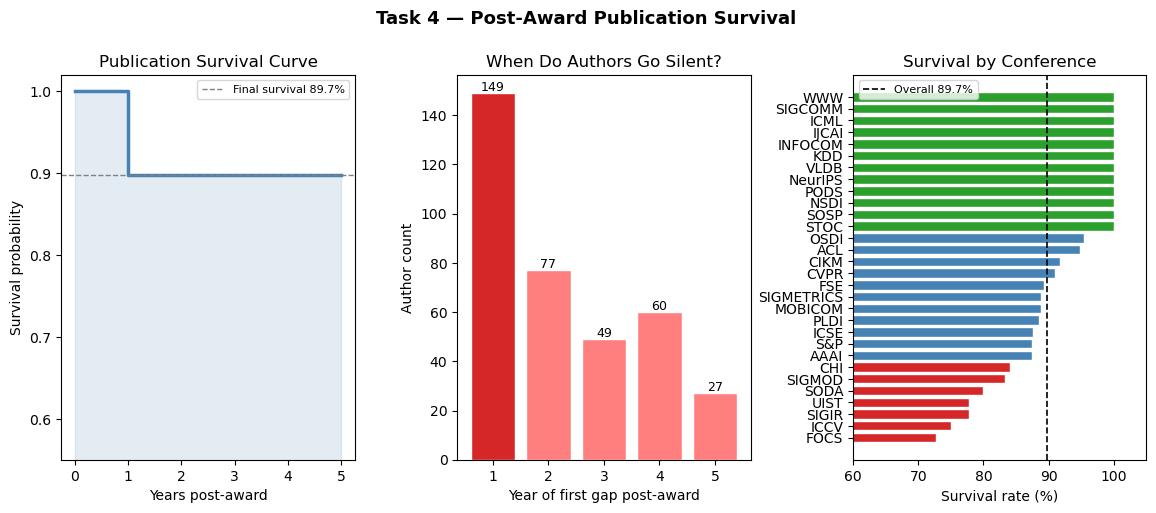

Saved.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: Kaplan-Meier style cumulative survival
ax1 = fig.add_subplot(gs[0])
total = len(df_surv)
at_risk = total
# True events: only the 62 permanent dropouts
# Censored: everyone still publishing at end of window

surv_probs = [1.0]
times = [0]
remaining = total

for lag in range(1, 6):
    # True dropout = no publications in ANY year from lag to end of window
    true_dropout_at_lag = df_surv[
        (df_surv['survived'] == 0) &
        (df_surv['dropout_lag'] == lag)
    ].shape[0]
    remaining -= true_dropout_at_lag
    surv_probs.append(remaining / total)
    times.append(lag)

# This will now correctly end near 0.897

ax1.step(times, surv_probs, where='post', color='steelblue', lw=2.5)
ax1.fill_between(times, surv_probs, step='post', alpha=0.15, color='steelblue')
ax1.set_xlabel("Years post-award")
ax1.set_ylabel("Survival probability")
ax1.set_title("Publication Survival Curve")
ax1.set_ylim(0.55, 1.02)
ax1.axhline(0.897, color='gray', ls='--', lw=1, label='Final survival 89.7%')
ax1.legend(fontsize=8)

# ── Panel 2: Dropout timing bar
ax2 = fig.add_subplot(gs[1])
lags = [1, 2, 3, 4, 5]
counts = [149, 77, 49, 60, 27]
ax2.bar(lags, counts, color=['#d62728' if i==0 else '#ff7f7e' for i in range(5)], edgecolor='white')
ax2.set_xlabel("Year of first gap post-award")
ax2.set_ylabel("Author count")
ax2.set_title("When Do Authors Go Silent?")
ax2.set_xticks(lags)
for i, (x, y) in enumerate(zip(lags, counts)):
    ax2.text(x, y+1, str(y), ha='center', fontsize=9)

# ── Panel 3: Survival rate by conference (top/bottom 8)
ax3 = fig.add_subplot(gs[2])
conf_surv = df_surv.groupby('conference')['survived'].agg(['mean','count'])
conf_surv = conf_surv[conf_surv['count'] >= 5].sort_values('mean')
colors = ['#d62728' if v < 0.85 else '#2ca02c' if v == 1.0 else 'steelblue' for v in conf_surv['mean']]
ax3.barh(conf_surv.index, conf_surv['mean']*100, color=colors, edgecolor='white')
ax3.axvline(89.7, color='black', ls='--', lw=1.2, label='Overall 89.7%')
ax3.set_xlabel("Survival rate (%)")
ax3.set_title("Survival by Conference")
ax3.legend(fontsize=8)
ax3.set_xlim(60, 105)

plt.suptitle("Task 4 — Post-Award Publication Survival", fontsize=13, fontweight='bold', y=1.01)
plt.savefig(DATA / "figures/task4_survival.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

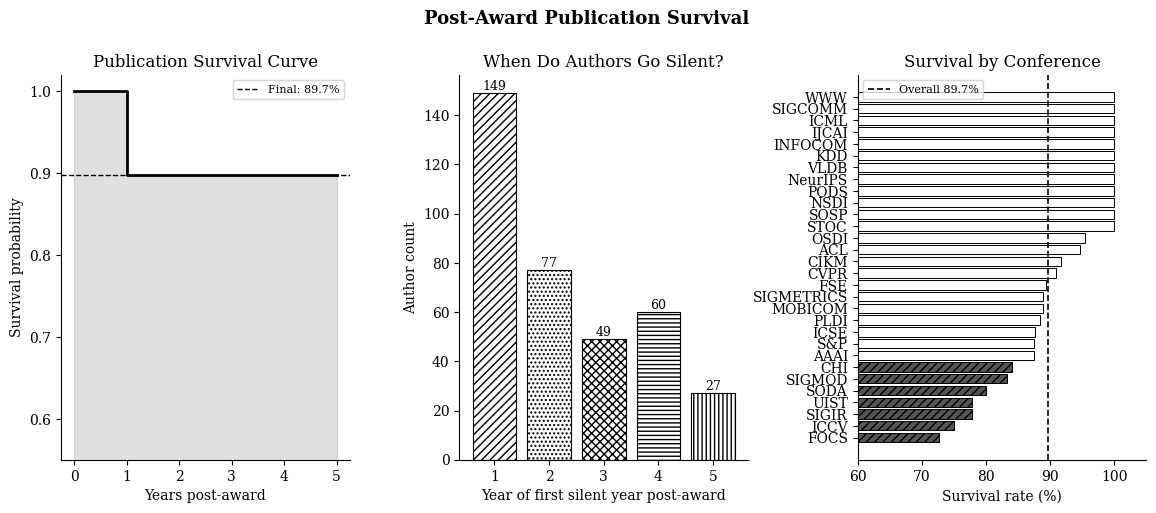

Saved.


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'grid.color': '#cccccc',
    'grid.linewidth': 0.5,
})

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

total = len(df_surv)

# ── Panel 1: Corrected KM-style survival (true dropouts only)
ax1 = fig.add_subplot(gs[0])
times = [0]
surv_probs = [1.0]
remaining = total
for lag in range(1, 6):
    true_drop = df_surv[(df_surv['survived']==0) & (df_surv['dropout_lag']==lag)].shape[0]
    remaining -= true_drop
    surv_probs.append(remaining / total)
    times.append(lag)

ax1.step(times, surv_probs, where='post', color='black', lw=2)
ax1.fill_between(times, surv_probs, step='post', alpha=0.12, color='black')
ax1.axhline(surv_probs[-1], color='black', ls='--', lw=1,
            label=f'Final: {surv_probs[-1]*100:.1f}%')
ax1.set_xlabel("Years post-award")
ax1.set_ylabel("Survival probability")
ax1.set_title("Publication Survival Curve")
ax1.set_ylim(0.55, 1.02)
ax1.set_xticks(range(0, 6))
ax1.legend(fontsize=8)

# ── Panel 2: Dropout timing bar (first silent year, incl. temporary gaps)
ax2 = fig.add_subplot(gs[1])
lags = [1, 2, 3, 4, 5]
counts = [149, 77, 49, 60, 27]
hatches = ['////', '....', 'xxxx', '----', '||||']
for x, c, h in zip(lags, counts, hatches):
    ax2.bar(x, c, color='white', edgecolor='black', linewidth=0.8, hatch=h)
    ax2.text(x, c + 1.5, str(c), ha='center', fontsize=9)
ax2.set_xlabel("Year of first silent year post-award")
ax2.set_ylabel("Author count")
ax2.set_title("When Do Authors Go Silent?")
ax2.set_xticks(lags)

# ── Panel 3: Survival by conference (B&W with hatching)
ax3 = fig.add_subplot(gs[2])
conf_surv = df_surv.groupby('conference')['survived'].agg(['mean','count'])
conf_surv = conf_surv[conf_surv['count'] >= 5].sort_values('mean')
colors = ['#555555' if v < 0.85 else 'white' for v in conf_surv['mean']]
hatches3 = ['////' if v < 0.85 else '' for v in conf_surv['mean']]
bars = ax3.barh(conf_surv.index, conf_surv['mean']*100,
                color=colors, edgecolor='black', linewidth=0.7)
for bar, h in zip(bars, hatches3):
    bar.set_hatch(h)
ax3.axvline(89.7, color='black', ls='--', lw=1.2, label='Overall 89.7%')
ax3.set_xlabel("Survival rate (%)")
ax3.set_title("Survival by Conference")
ax3.legend(fontsize=8)
ax3.set_xlim(60, 105)

plt.suptitle("Post-Award Publication Survival", fontsize=13, fontweight='bold', y=1.01)
plt.savefig(DATA / "figures/task4_survival_bw.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

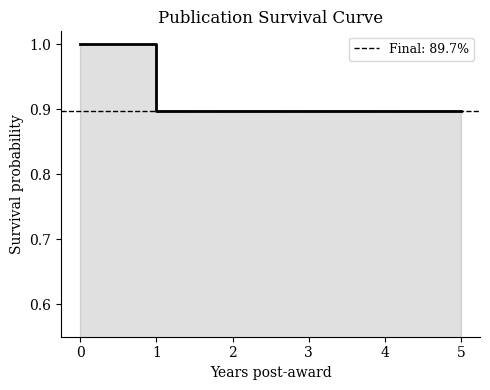

Fig 1 saved.


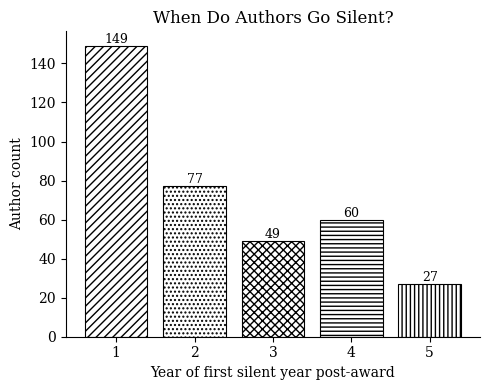

Fig 2 saved.


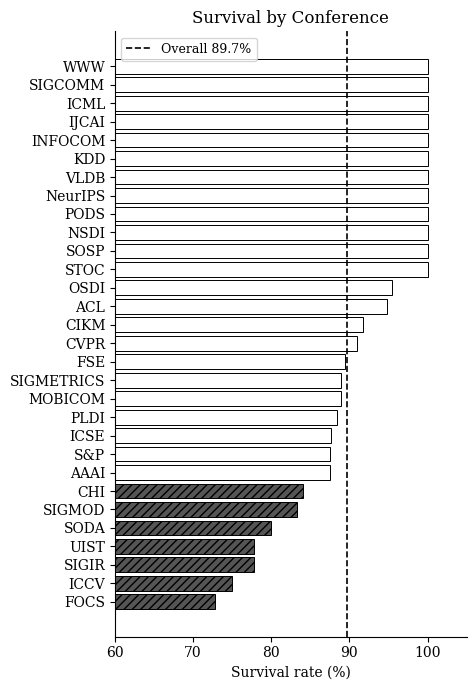

Fig 3 saved.


In [17]:
plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
})

total = len(df_surv)

# ── Figure 1: Survival Curve
fig, ax1 = plt.subplots(figsize=(5, 4))
times = [0]; surv_probs = [1.0]; remaining = total
for lag in range(1, 6):
    true_drop = df_surv[(df_surv['survived']==0) & (df_surv['dropout_lag']==lag)].shape[0]
    remaining -= true_drop
    surv_probs.append(remaining / total)
    times.append(lag)
ax1.step(times, surv_probs, where='post', color='black', lw=2)
ax1.fill_between(times, surv_probs, step='post', alpha=0.12, color='black')
ax1.axhline(surv_probs[-1], color='black', ls='--', lw=1, label=f'Final: {surv_probs[-1]*100:.1f}%')
ax1.set_xlabel("Years post-award"); ax1.set_ylabel("Survival probability")
ax1.set_title("Publication Survival Curve")
ax1.set_ylim(0.55, 1.02); ax1.set_xticks(range(0, 6))
ax1.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA / "figures/23_fig1_survival_curve.png", dpi=150, bbox_inches='tight')
plt.show(); print("Fig 1 saved.")

# ── Figure 2: When Do Authors Go Silent?
fig, ax2 = plt.subplots(figsize=(5, 4))
lags = [1, 2, 3, 4, 5]; counts = [149, 77, 49, 60, 27]
hatches = ['////', '....', 'xxxx', '----', '||||']
for x, c, h in zip(lags, counts, hatches):
    ax2.bar(x, c, color='white', edgecolor='black', linewidth=0.8, hatch=h)
    ax2.text(x, c + 1.5, str(c), ha='center', fontsize=9)
ax2.set_xlabel("Year of first silent year post-award"); ax2.set_ylabel("Author count")
ax2.set_title("When Do Authors Go Silent?"); ax2.set_xticks(lags)
plt.tight_layout()
plt.savefig(DATA / "figures/23_fig2_dropout_timing.png", dpi=150, bbox_inches='tight')
plt.show(); print("Fig 2 saved.")

# ── Figure 3: Survival by Conference
fig, ax3 = plt.subplots(figsize=(5, 7))
conf_surv = df_surv.groupby('conference')['survived'].agg(['mean','count'])
conf_surv = conf_surv[conf_surv['count'] >= 5].sort_values('mean')
colors = ['#555555' if v < 0.85 else 'white' for v in conf_surv['mean']]
hatches3 = ['////' if v < 0.85 else '' for v in conf_surv['mean']]
bars = ax3.barh(conf_surv.index, conf_surv['mean']*100, color=colors, edgecolor='black', linewidth=0.7)
for bar, h in zip(bars, hatches3): bar.set_hatch(h)
ax3.axvline(89.7, color='black', ls='--', lw=1.2, label='Overall 89.7%')
ax3.set_xlabel("Survival rate (%)"); ax3.set_title("Survival by Conference")
ax3.legend(fontsize=9); ax3.set_xlim(60, 105)
plt.tight_layout()
plt.savefig(DATA/ "figures/23_fig3_conference_survival.png", dpi=150, bbox_inches='tight')
plt.show(); print("Fig 3 saved.")